# Calibrating SIPNET parameters with MCMC

This example walks through a small but realistic parameter-calibration workflow: we
estimate two carbon-cycle parameters of SIPNET from a time series of net ecosystem
exchange (NEE), the quantity measured at eddy-covariance flux towers.

We calibrate:

| Parameter | Role | Effect on NEE |
|---|---|---|
| `aMax` | maximum photosynthetic capacity | ↑ `aMax` → more uptake → **lower** NEE |
| `baseSoilResp` | base soil (heterotrophic) respiration rate | ↑ `baseSoilResp` → more release → **higher** NEE |

Because these two act in *opposite* directions on NEE, the data constrain their
*difference* more tightly than either one alone — a mild version of the "equifinality"
that pervades land-model calibration, and something we will see directly in the shape
of the posterior.

**The point of this example** is to show how pySIPNET drops into a standard Bayesian
workflow as a black-box forward model. We deliberately write our *own* tiny
Metropolis–Hastings sampler that knows nothing about pySIPNET — it only sees an
unnormalized log-density. Anything that accepts such a callable (`emcee`, `PyMC`'s
custom densities, `zeus`, an SMC sampler, …) plugs in the same way.

> **Scope.** This is a workflow illustration, not a statistics tutorial. We use a
> synthetic "identical-twin" experiment (generate data from known parameters, then try
> to recover them), a hand-tuned proposal, and a single chain. Convergence diagnostics,
> proposal adaptation, a realistic (heteroscedastic) NEE error model, and soil-carbon
> spin-up are all out of scope — see the closing notes.

> **Requires the compiled SIPNET binary.** Build it once from the repo root with
> `make sipnet-standard`.

## 1. Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pysipnet.climate import ClimateDrivers
from pysipnet.io.clim_io import read_clim_file
from pysipnet.parameters.model import (
    AllocationParams,
    InitialConditions,
    LeafPhysiologyParams,
    PhenologyParams,
    PhotosynthesisParams,
    RespirationParams,
    SIPNETParameters,
    WaterParams,
)
from pysipnet.parameters.model import ModelFlags
from pysipnet.model import SIPNETModel
from pysipnet.runner import SIPNETRunner

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3})

In [2]:
# One year of daily meteorological forcing for the Niwot Ridge subalpine forest
# (aggregated from the SIPNET example driver; see data/README.md).
CLIM_PATH = Path("data/niwot_1999_daily.clim")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # a few days have vpd <= 0; SIPNET clamps internally
    climate = read_clim_file(CLIM_PATH, n_columns=14)

print(climate)

ClimateDrivers(n_columns=14, timesteps=365, range=1999-001 to 1999-365)


## 2. The forward model

All parameters are held fixed at nominal Niwot Ridge values except the two we calibrate.
Rather than rebuild the full parameter set on every run, we use `SIPNETModel` — the
recommended high-level interface. It stores the baseline parameters, model flags, and
climate once, and each call overrides only the parameters that change:

```python
model = SIPNETModel(runner, base_params=base_params, base_climate=climate)
model(a_max=12.0, base_soil_resp=0.06)   # run with just these two overridden
```

`SIPNETModel` is a plain callable with the shape `(**overrides) -> result`, which is
exactly what a sampler or ensemble framework wants — so our `daily_nee` forward map is a
one-liner on top of it.

SIPNET's sign convention is **positive NEE = net carbon release to the atmosphere**
(a source); negative NEE is net uptake (a sink).

In [3]:
# Nominal Niwot Ridge parameters. Every value here is held fixed during
# calibration except a_max and base_soil_resp, which SIPNETModel overrides on
# each call (the values set for them below are placeholders).
base_params = SIPNETParameters(
    initial_conditions=InitialConditions(
        plant_wood=9600.0, lai=4.2, litter=400.0, soil=16000.0,
        litter_water_frac=0.5, soil_water_frac=0.5, snow=0.0,
        fine_root_frac=0.2, coarse_root_frac=0.2,
    ),
    photosynthesis=PhotosynthesisParams(
        a_max=10.0,                        # placeholder; calibrated (overridden per call)
        a_max_frac=0.76, base_fol_resp_frac=0.1, psn_t_min=2.0, psn_t_opt=24.0,
        d_vpd_slope=0.05, d_vpd_exp=2.0, half_sat_par=17.0, attenuation=0.5,
    ),
    phenology=PhenologyParams(
        leaf_on_day=144.0, leaf_off_day=285.0, gdd_leaf_on=500.0,
        soil_temp_leaf_on=12.0, leaf_growth=0.0, frac_leaf_fall=0.0,
        leaf_allocation=0.2, leaf_turnover_rate=0.13,
    ),
    respiration=RespirationParams(
        base_soil_resp=0.05,               # placeholder; calibrated (overridden per call)
        base_veg_resp=0.006, veg_resp_q10=2.0, growth_resp_frac=0.2,
        frozen_soil_fol_r_eff=0.0, frozen_soil_threshold=0.0,
        base_fine_root_resp=0.09, base_coarse_root_resp=0.006,
        fine_root_q10=2.6, coarse_root_q10=2.6, soil_resp_q10=2.9,
        soil_resp_moist_effect=1.0,
    ),
    allocation=AllocationParams(
        fine_root_allocation=0.4, wood_allocation=0.2,
        fine_root_turnover_rate=0.137, coarse_root_turnover_rate=0.056,
        wood_turnover_rate=0.014,
    ),
    water=WaterParams(
        water_remove_frac=0.088, frozen_soil_eff=0.0, wue_const=10.9,
        soil_whc=12.0, immed_evap_frac=0.1, fast_flow_frac=0.1,
        snow_melt=0.15, rd_const=36.5, r_soil_const1=8.2, r_soil_const2=4.3,
    ),
    leaf=LeafPhysiologyParams(leaf_c_sp_wt=270.0, c_frac_leaf=0.45),
)

runner = SIPNETRunner(flags=ModelFlags.standard())
model = SIPNETModel(runner, base_params=base_params, base_climate=climate)


def daily_nee(a_max: float, base_soil_resp: float) -> np.ndarray:
    '''Forward map: the two calibrated params -> daily NEE (g C m-2 day-1, +ve = source).'''
    result = model(a_max=a_max, base_soil_resp=base_soil_resp)
    return result.nee().to_numpy()

## 3. Observations: monthly-mean NEE

Real calibrations often compare against aggregated fluxes rather than every timestep.
We use **monthly-mean NEE** (12 numbers). Aggregating also smooths high-frequency noise
and keeps the inference problem low-information enough that the posterior is not too 
concentrated, which is nice for visualization purposes in this introductory example.

In [4]:
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]  # 1999, non-leap
_edges = np.cumsum([0] + DAYS_IN_MONTH)
_month_of_doy = np.searchsorted(_edges, np.arange(1, 366), side="right") - 1
_month_mid_doy = (_edges[:-1] + _edges[1:]) / 2.0


def monthly_mean(daily: np.ndarray) -> np.ndarray:
    '''Aggregate a 365-day series into 12 monthly means.'''
    return np.array([daily[_month_of_doy == m].mean() for m in range(12)])

## 4. Synthetic truth and data (identical-twin experiment)

We pick "true" parameter values, run SIPNET to get the true latent NEE, aggregate to
monthly means, and add Gaussian observation noise. Calibration then tries to recover the
known truth.

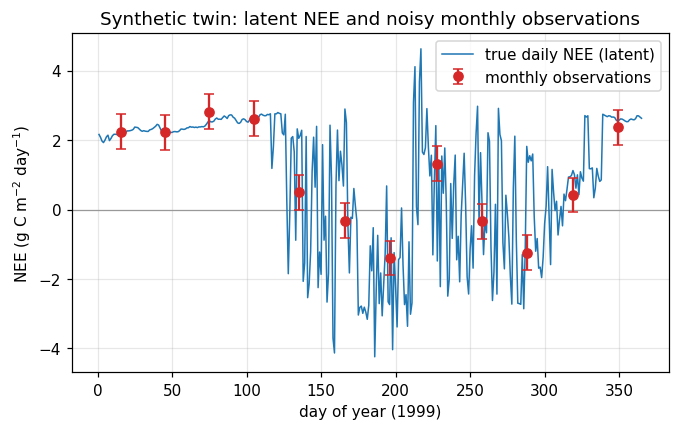

In [5]:
A_TRUE, B_TRUE = 10.0, 0.05     # true aMax, baseSoilResp
SIGMA = 0.5                     # obs noise SD on monthly-mean NEE (g C m-2 day-1)

nee_true_daily = daily_nee(A_TRUE, B_TRUE)
obs_true_monthly = monthly_mean(nee_true_daily)

rng_data = np.random.default_rng(0)
obs = obs_true_monthly + rng_data.normal(0.0, SIGMA, size=12)

fig, ax = plt.subplots()
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(np.arange(1, 366), nee_true_daily, color="C0", lw=1, label="true daily NEE (latent)")
ax.errorbar(_month_mid_doy, obs, yerr=SIGMA, fmt="o", color="C3", capsize=3,
            label="monthly observations")
ax.set(xlabel="day of year (1999)", ylabel="NEE (g C m$^{-2}$ day$^{-1}$)",
       title="Synthetic twin: latent NEE and noisy monthly observations")
ax.legend()
plt.show()

## 5. Unconstrained parameters and priors

Both parameters are strictly positive, so we sample in **log space**:
$\theta = (\log a_{\max},\ \log \texttt{baseSoilResp})$. The sampler then moves over all of
$\mathbb{R}^2$ and never proposes an invalid negative value.

We state the priors *directly* as Gaussians on $\theta$ (equivalently, log-normal priors on
the natural parameters). Because the prior is defined in the same space we sample in, the
target is simply `log_prior(θ) + log_likelihood(θ)` with **no Jacobian term** to track.

In [6]:
PRIOR_MEAN = np.array([np.log(9.0), np.log(0.055)])   # centered near, but not on, the truth
PRIOR_SD = np.array([0.35, 0.40])


def to_natural(theta: np.ndarray) -> tuple[float, float]:
    a_max, base_soil_resp = np.exp(theta)
    return float(a_max), float(base_soil_resp)


def log_prior(theta: np.ndarray) -> float:
    return float(np.sum(-0.5 * ((theta - PRIOR_MEAN) / PRIOR_SD) ** 2))

## 6. Prior predictive check

Before calibrating, we push a few hundred prior draws through SIPNET to confirm the prior
implies *plausible* NEE trajectories that comfortably bracket the data — a quick, informal
sanity check, not a formal step.

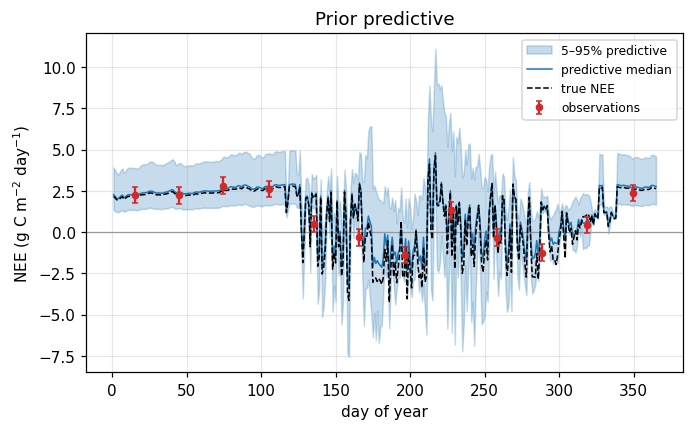

In [7]:
N_PRED = 200
rng_prior = np.random.default_rng(2)
prior_thetas = PRIOR_MEAN + PRIOR_SD * rng_prior.standard_normal((N_PRED, 2))
prior_pred = np.array([daily_nee(*np.exp(th)) for th in prior_thetas])


def plot_predictive(ax, pred, title):
    lo, mid, hi = np.percentile(pred, [5, 50, 95], axis=0)
    days = np.arange(1, 366)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.fill_between(days, lo, hi, color="C0", alpha=0.25, label="5–95% predictive")
    ax.plot(days, mid, color="C0", lw=1, label="predictive median")
    ax.plot(days, nee_true_daily, color="k", lw=1, ls="--", label="true NEE")
    ax.errorbar(_month_mid_doy, obs, yerr=SIGMA, fmt="o", color="C3", ms=4, capsize=2,
                label="observations")
    ax.set(xlabel="day of year", ylabel="NEE (g C m$^{-2}$ day$^{-1}$)", title=title)
    ax.legend(fontsize=8)


fig, ax = plt.subplots()
plot_predictive(ax, prior_pred, "Prior predictive")
plt.show()

## 7. A standalone Metropolis–Hastings sampler

Here is the entire sampler. Note its **only dependency is NumPy** — it has no idea SIPNET
exists. It takes a black-box `log_prob` callable and a fixed Gaussian proposal covariance
(random-walk Metropolis). This is the interface almost every general-purpose sampler
exposes, which is exactly the point: pySIPNET lives *behind* `log_prob`, not inside the
sampler.

In [8]:
def metropolis_hastings(log_prob, x0, proposal_cov, n_samples, rng):
    '''Random-walk Metropolis-Hastings for a black-box unnormalized log-density.

    Parameters
    ----------
    log_prob : callable(np.ndarray) -> float
        Unnormalized log-density. Opaque to the sampler.
    x0 : array_like
        Starting point.
    proposal_cov : (d, d) array
        Covariance of the Gaussian random-walk proposal (tuned offline here).
    n_samples : int
        Number of iterations (each yields one sample, including rejections).
    rng : np.random.Generator

    Returns
    -------
    (samples, acceptance_rate)
    '''
    x = np.asarray(x0, dtype=float)
    log_p = log_prob(x)
    chol = np.linalg.cholesky(proposal_cov)
    dim = x.size
    samples = np.empty((n_samples, dim))
    n_accept = 0
    for i in range(n_samples):
        proposal = x + chol @ rng.standard_normal(dim)
        log_p_prop = log_prob(proposal)
        if np.log(rng.random()) < log_p_prop - log_p:   # Metropolis acceptance
            x, log_p = proposal, log_p_prop
            n_accept += 1
        samples[i] = x
    return samples, n_accept / n_samples

## 8. Plugging pySIPNET in: the log-posterior

This closure is the *only* place SIPNET is called during sampling. It maps
$\theta \to$ SIPNET NEE $\to$ Gaussian log-likelihood, and adds the log-prior. To the
sampler it is just a function $\mathbb{R}^2 \to \mathbb{R}$.

In [9]:
def log_likelihood(theta: np.ndarray) -> float:
    a_max, base_soil_resp = np.exp(theta)
    pred = monthly_mean(daily_nee(a_max, base_soil_resp))
    return float(np.sum(-0.5 * ((pred - obs) / SIGMA) ** 2))


def log_posterior(theta: np.ndarray) -> float:
    return log_prior(theta) + log_likelihood(theta)

## 9. Run the chain

The proposal covariance below was tuned offline so the acceptance rate lands near the
0.2–0.4 range that works well for a 2-D random walk, with the proposal oriented along the
posterior's correlated ridge. (In practice you would adapt it or use an ensemble/HMC
sampler; we hard-code it to keep the example self-contained.)

In [10]:
PROPOSAL_COV = np.array([[0.017, 0.015],
                         [0.015, 0.029]])
N_ITER = 4000
BURN_IN = 1000

rng_mcmc = np.random.default_rng(1)
chain, accept_rate = metropolis_hastings(
    log_posterior, x0=PRIOR_MEAN.copy(), proposal_cov=PROPOSAL_COV,
    n_samples=N_ITER, rng=rng_mcmc,
)
posterior = chain[BURN_IN:]
print(f"acceptance rate : {accept_rate:.2f}")
print(f"kept samples    : {len(posterior)} (of {N_ITER}, after {BURN_IN} burn-in)")
post_amax = np.exp(posterior[:, 0])
post_bsr = np.exp(posterior[:, 1])
print(f"posterior aMax          : {post_amax.mean():.2f} ± {post_amax.std():.2f}  (true {A_TRUE})")
print(f"posterior baseSoilResp  : {post_bsr.mean():.4f} ± {post_bsr.std():.4f}  (true {B_TRUE})")

acceptance rate : 0.34
kept samples    : 3000 (of 4000, after 1000 burn-in)
posterior aMax          : 10.05 ± 0.76  (true 10.0)
posterior baseSoilResp  : 0.0526 ± 0.0051  (true 0.05)


## 10. Trace plots

A quick look at mixing and burn-in.

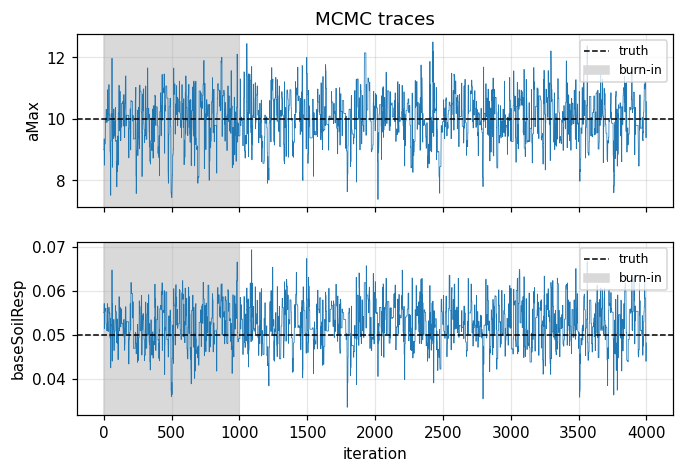

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True)
for ax, series, label, truth in zip(
    axes, [np.exp(chain[:, 0]), np.exp(chain[:, 1])],
    ["aMax", "baseSoilResp"], [A_TRUE, B_TRUE],
):
    ax.plot(series, lw=0.5, color="C0")
    ax.axhline(truth, color="k", ls="--", lw=1, label="truth")
    ax.axvspan(0, BURN_IN, color="0.85", label="burn-in")
    ax.set_ylabel(label)
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("iteration")
axes[0].set_title("MCMC traces")
plt.show()

## 11. Posterior vs. prior vs. truth

The posterior is far tighter than the prior and concentrates near the true values. Its
tilt reflects the `aMax`–`baseSoilResp` trade-off: a bit more photosynthetic uptake can be
offset by a bit more respiration and still match the observed NEE.

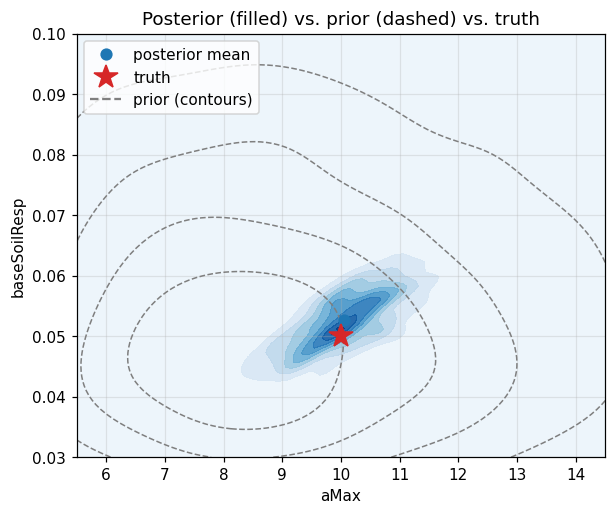

In [12]:
def kde_2d(samples, XX, YY):
    '''Tiny Gaussian KDE (Scott's rule) evaluated on a grid; NumPy only.'''
    n = samples.shape[0]
    H = np.cov(samples.T) * n ** (-1.0 / 3.0)   # Scott: h^2 with h = n^(-1/(d+4)), d=2
    Hinv = np.linalg.inv(H)
    norm = 1.0 / (2 * np.pi * np.sqrt(np.linalg.det(H)) * n)
    pts = np.column_stack([XX.ravel(), YY.ravel()])
    dens = np.zeros(pts.shape[0])
    for s in samples:
        diff = pts - s
        dens += np.exp(-0.5 * np.einsum("ij,jk,ik->i", diff, Hinv, diff))
    return (norm * dens).reshape(XX.shape)


# prior draws (for a fair prior-vs-posterior comparison in natural space)
rng_pr = np.random.default_rng(7)
prior_draws = np.exp(PRIOR_MEAN + PRIOR_SD * rng_pr.standard_normal((4000, 2)))
post_draws = np.column_stack([post_amax, post_bsr])

ax_grid = np.linspace(5.5, 14.5, 90)
bx_grid = np.linspace(0.03, 0.10, 90)
XX, YY = np.meshgrid(ax_grid, bx_grid)
prior_d = kde_2d(prior_draws, XX, YY)
post_d = kde_2d(post_draws, XX, YY)

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.contour(XX, YY, prior_d, levels=4, colors="C7", linestyles="--", linewidths=1)
ax.contourf(XX, YY, post_d, levels=8, cmap="Blues", alpha=0.9)
ax.plot(post_amax.mean(), post_bsr.mean(), "o", color="C0", ms=7, label="posterior mean")
ax.plot(A_TRUE, B_TRUE, "*", color="C3", ms=16, label="truth")
ax.plot([], [], "--", color="C7", label="prior (contours)")
ax.set(xlabel="aMax", ylabel="baseSoilResp",
       title="Posterior (filled) vs. prior (dashed) vs. truth")
ax.legend(loc="upper left")
plt.show()

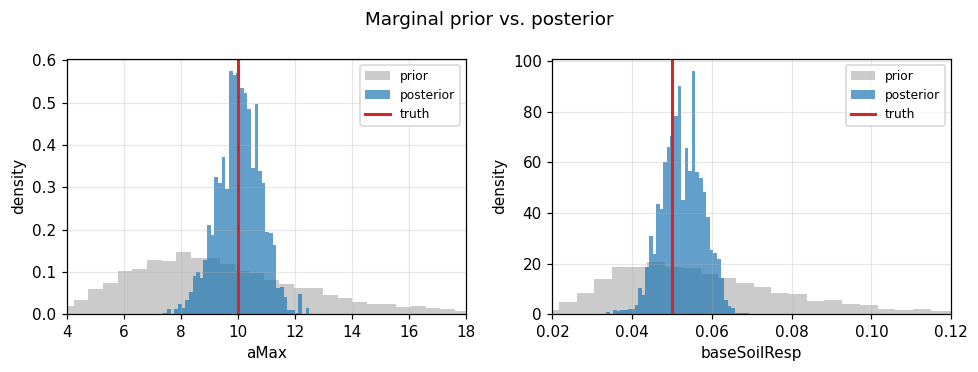

In [13]:
# marginal posteriors vs priors
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, post, prior, label, truth in zip(
    axes, [post_amax, post_bsr], [prior_draws[:, 0], prior_draws[:, 1]],
    ["aMax", "baseSoilResp"], [A_TRUE, B_TRUE],
):
    ax.hist(prior, bins=60, density=True, color="C7", alpha=0.4, label="prior")
    ax.hist(post, bins=40, density=True, color="C0", alpha=0.7, label="posterior")
    ax.axvline(truth, color="C3", lw=2, label="truth")
    ax.set(xlabel=label, ylabel="density")
    ax.legend(fontsize=8)
axes[0].set_xlim(4, 18)
axes[1].set_xlim(0.02, 0.12)
fig.suptitle("Marginal prior vs. posterior")
fig.tight_layout()
plt.show()

## 12. Posterior predictive vs. prior predictive

Finally we push posterior draws back through SIPNET. The posterior predictive collapses
onto the true signal and the data, in contrast to the broad prior predictive — the
calibration has sharpened our prediction of the flux, not just the parameters.

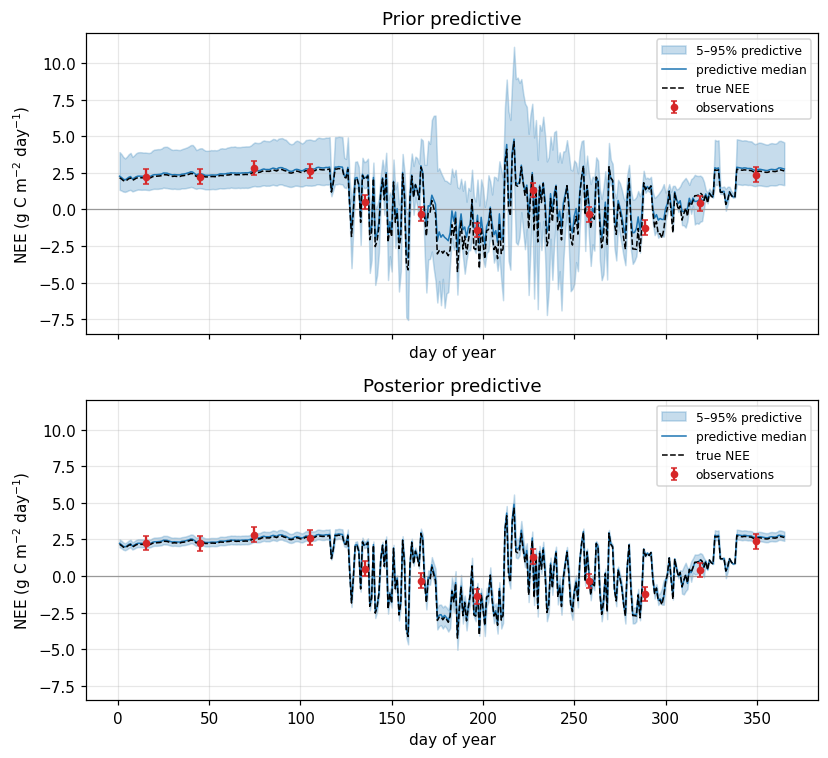

In [14]:
rng_post = np.random.default_rng(3)
idx = rng_post.choice(len(posterior), size=N_PRED, replace=False)
post_pred = np.array([daily_nee(*np.exp(posterior[i])) for i in idx])

fig, axes = plt.subplots(2, 1, figsize=(7.5, 7), sharex=True, sharey=True)
plot_predictive(axes[0], prior_pred, "Prior predictive")
plot_predictive(axes[1], post_pred, "Posterior predictive")
fig.tight_layout()
plt.show()

## 13. Takeaways and extensions

- pySIPNET acted as a **black-box forward model**: the sampler only ever saw
  `log_posterior(θ)`. Swapping our teaching sampler for `emcee`, `PyMC`, `zeus`, or an SMC
  method would leave the SIPNET-facing code unchanged.
- Working in **log space** kept the sampler unconstrained and let us skip a change-of-
  variables term by stating the priors there directly.
- The posterior recovered the true parameters and revealed the expected
  `aMax`–`baseSoilResp` **trade-off** — a small, honest taste of equifinality.

To move from this illustration toward research practice you would, among other things:

- replace the fixed-σ Gaussian likelihood with a **heteroscedastic / double-exponential**
  NEE error model, and often infer σ jointly;
- calibrate **more parameters**, where hand-tuning a proposal stops working — motivating
  adaptive MCMC, ensemble samplers, gradient-based HMC, or emulator-based / active-learning
  approaches for expensive models;
- run **multiple chains** with convergence diagnostics (e.g. $\hat{R}$), and spin up the
  soil-carbon pools before the calibration window;
- calibrate against **real** flux-tower NEE (with gaps and u\* filtering) rather than a
  synthetic twin.